Import libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import the data set

In [14]:
df = pd.read_csv('/content/diabetes.csv')
print('library imported succefuuly')

library imported succefuuly


Explore the Data

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Some Analysis

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

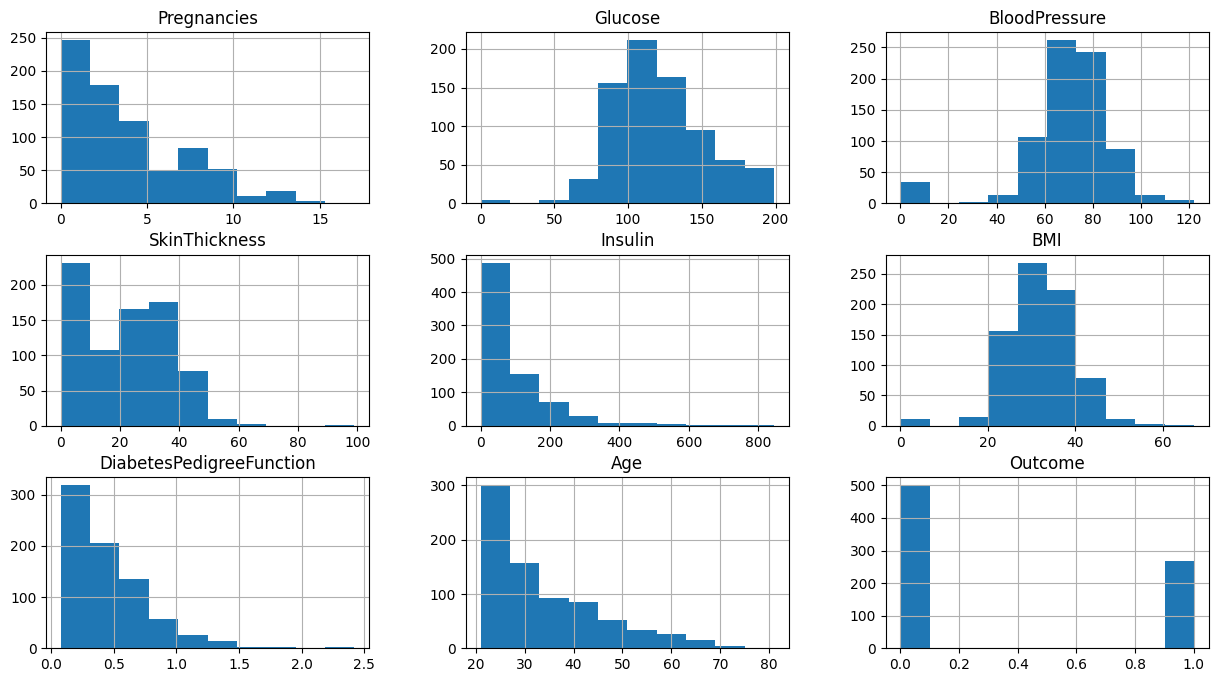

In [19]:
df.hist(figsize=(15,8))

In [20]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

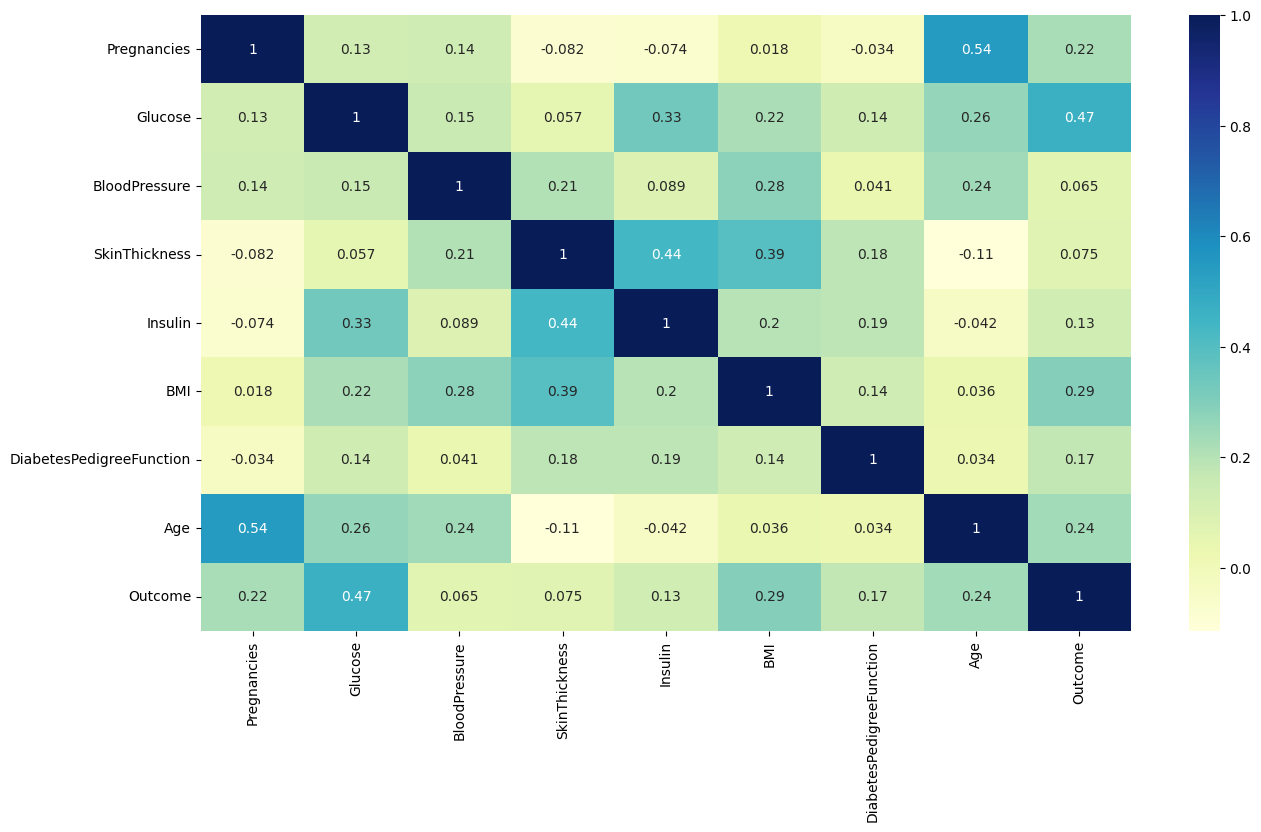

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')

In [22]:
from sklearn.model_selection import train_test_split
x = df.drop(['Outcome'], axis=1)
y = df['Outcome']

Standaradize the Data

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x_s = scaler.transform(x)
x_s = pd.DataFrame(x_s, columns=x.columns)
df_s = pd.concat([x_s, y], axis=1)

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

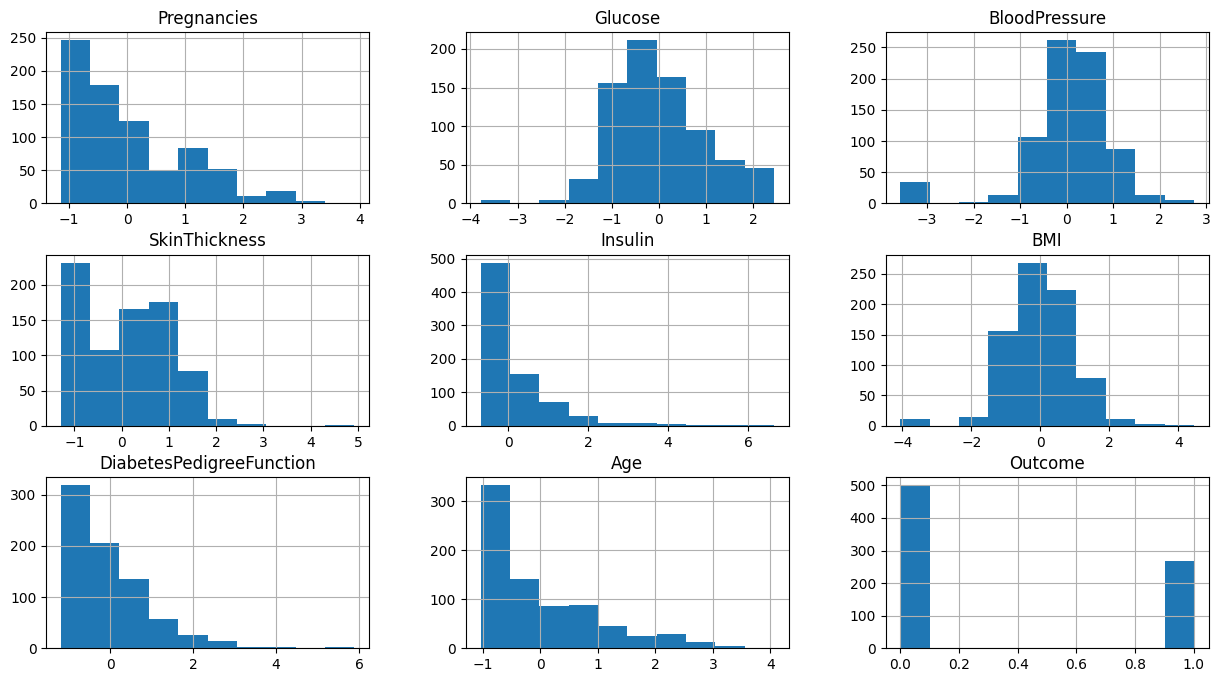

In [24]:
df_s = pd.DataFrame(df_s, columns=df.columns)
df_s.hist(figsize=(15,8))

<Axes: >

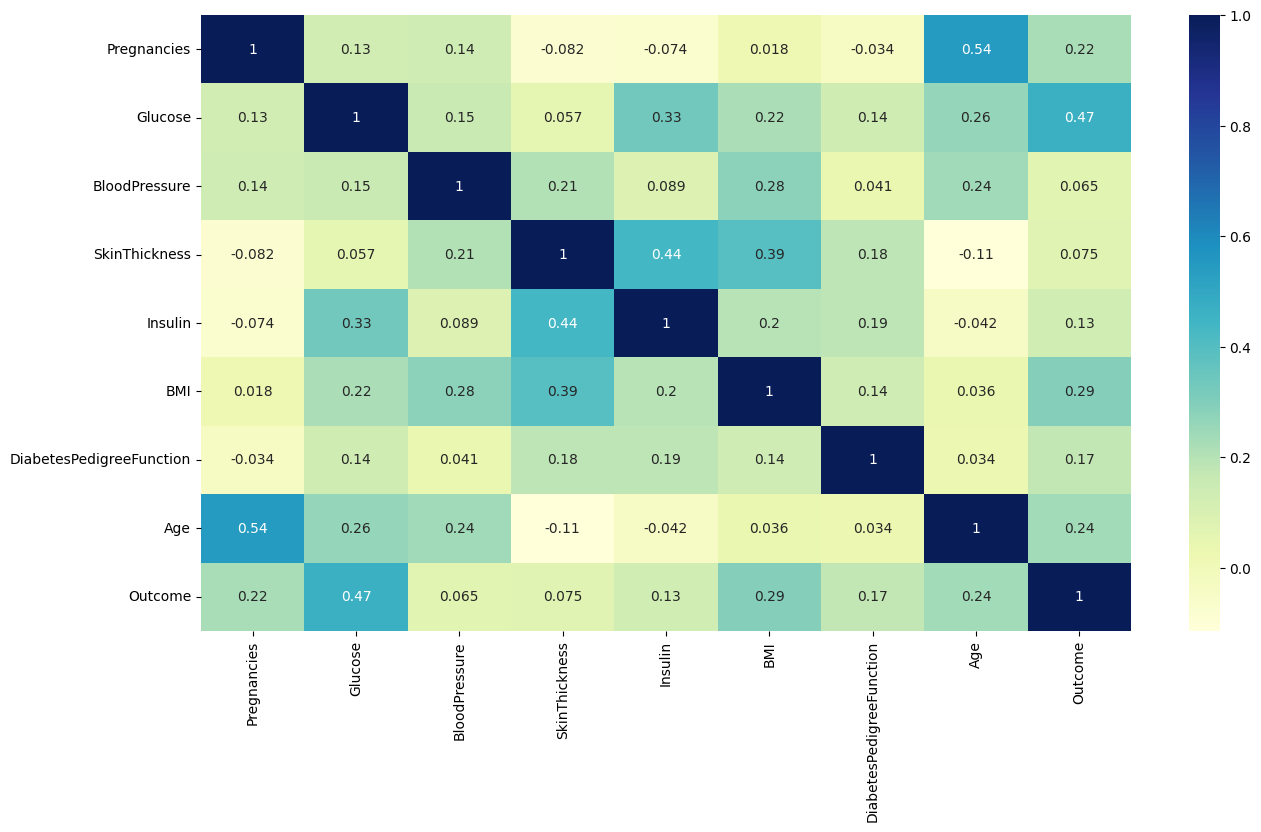

In [25]:
plt.figure(figsize=(15,8))
sns.heatmap(df_s.corr(), annot=True, cmap='YlGnBu')

**Applying the Models**

Split the data


In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

First Model Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
reg = LinearRegression()
reg.fit(x_train, y_train)
result_1 = reg.predict(x_test)

In [28]:
# Threshold the continuous predictions to make them binary
result_1_binary = (result_1 > 0.5).astype(int)

print("First Model Linear Regression Results")
print(confusion_matrix(y_test, result_1_binary))
print(classification_report(y_test, result_1_binary))
print("ROC-AUC:", roc_auc_score(y_test, result_1))

First Model Linear Regression Results
[[80 19]
 [18 37]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

ROC-AUC: 0.8135904499540864


Second Model Random Forest


Without Hyperparameter tuning

In [29]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
forest.fit(x_train, y_train)
forest.score(x_test, y_test)
result_2 = forest.predict(x_test)

In [30]:
result_2_binary = (result_2 > 0.5).astype(int)

print("Second Model Random Forest without tuning Results")
print(confusion_matrix(y_test, result_2_binary))
print(classification_report(y_test, result_2_binary))
print("ROC-AUC:", roc_auc_score(y_test, result_2_binary))

Second Model Random Forest without tuning Results
[[77 22]
 [16 39]]
              precision    recall  f1-score   support

           0       0.83      0.78      0.80        99
           1       0.64      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154

ROC-AUC: 0.7434343434343433


With Hyperparameter tuning

In [31]:
from sklearn.model_selection import GridSearchCV
forest = RandomForestRegressor()
param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8]
}

grid_search = GridSearchCV(forest, param_grid, cv=5,
                           scoring="neg_mean_squared_error",
                           return_train_score=True)

grid_search.fit(x_train, y_train)

grid_search.best_estimator_
#grid_search.best_estimator_.score(x_test, y_test)
result_3 = grid_search.best_estimator_.predict(x_test)

In [32]:
result_3_binary = (result_3 > 0.5).astype(int)

print("Second Model Random Forest with tuning Results")
print(confusion_matrix(y_test, result_3_binary))
print(classification_report(y_test, result_3_binary))
print("ROC-AUC:", roc_auc_score(y_test, result_3_binary))

Second Model Random Forest with tuning Results
[[82 17]
 [19 36]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154

ROC-AUC: 0.7414141414141414


Third Model SVM

Without tuning gamma and c

In [33]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model_std = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42))  # Default C=1.0, gamma='scale'
])

model_std.fit(x_train, y_train)

result_4 = model_std.predict(x_test)

# Evaluate performance
accuracy_basic = accuracy_score(y_test, result_4)
print(f"Accuracy (Basic SVM): {accuracy_basic:.4f}")
print(f"Default parameters used: C=1.0, gamma='scale'")
print("\nClassification Report (Basic SVM):")
print(classification_report(y_test, result_4))
print("ROC-AUC:", roc_auc_score(y_test, result_4))

Accuracy (Basic SVM): 0.7338
Default parameters used: C=1.0, gamma='scale'

Classification Report (Basic SVM):
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

ROC-AUC: 0.6959595959595959


With Tuned gamma and c

In [34]:
model_tuned = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

# Define the parameter grid to search
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],           # Regularization parameter
    'classifier__gamma': [0.01, 0.1, 1, 10]       # Kernel coefficient
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=model_tuned,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    verbose=1,  # Shows progress
    n_jobs=-1   # Use all available processors
)

print("Starting hyperparameter tuning...")
print("Testing 16 different combinations of C and gamma...")

grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_
print(f"\nBest parameters found: {best_params}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

result_5 = grid_search.predict(x_test)

# Evaluate performance
accuracy_tuned = accuracy_score(y_test, result_5)
print(f"Accuracy (Tuned SVM): {accuracy_tuned:.4f}")
print(f"confusion Matrix (Tuned SVM): ")
print(confusion_matrix(y_test, result_5))
print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, result_5))
print("ROC-AUC:", roc_auc_score(y_test, result_5))


Starting hyperparameter tuning...
Testing 16 different combinations of C and gamma...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters found: {'classifier__C': 1, 'classifier__gamma': 0.1}
Best cross-validation score: 0.7720
Accuracy (Tuned SVM): 0.7338
confusion Matrix (Tuned SVM): 
[[83 16]
 [25 30]]

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        99
           1       0.65      0.55      0.59        55

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154

ROC-AUC: 0.6919191919191918


Comparing between the used models




In [35]:
print("Logistic Regression")
print("Accuracy: ",accuracy_score(y_test, result_1_binary))
print("ROC AUC: ",roc_auc_score(y_test, result_1_binary))
print()

print("Random Forest")
print("Accuracy: ",accuracy_score(y_test, result_2_binary))
print("ROC AUC: ",roc_auc_score(y_test, result_2_binary))
print("Tuned Accuracy: ",accuracy_score(y_test, result_3_binary))
print("Tuned ROC AUC: ",roc_auc_score(y_test, result_3_binary))
print()
print("SVM")
print("Accuracy: ",accuracy_score(y_test, result_4))
print("ROC AUC: ",roc_auc_score(y_test, result_4))
print("Tuned Accuracy: ",accuracy_score(y_test, result_5))
print("Tuned ROC AUC: ",roc_auc_score(y_test, result_5))
print()
print ("Tuned Random Forest is the best model")

Logistic Regression
Accuracy:  0.7597402597402597
ROC AUC:  0.7404040404040404

Random Forest
Accuracy:  0.7532467532467533
ROC AUC:  0.7434343434343433
Tuned Accuracy:  0.7662337662337663
Tuned ROC AUC:  0.7414141414141414

SVM
Accuracy:  0.7337662337662337
ROC AUC:  0.6959595959595959
Tuned Accuracy:  0.7337662337662337
Tuned ROC AUC:  0.6919191919191918

Tuned Random Forest is the best model


building a prediction function

In [76]:
def predict_diabetes(input_data):
    """
    Predict diabetes for a patient

    Parameters:
    input_data: list of patient measurements

    Returns:
    string: "Diabetic" or "Non-Diabetic"
    """
    input_array = np.array(input_data).reshape(1, -1)
    input_df = pd.DataFrame(input_array, columns=x_s.columns)
    StandardScaler()
    scaler2 = StandardScaler()
    scaler2.fit(x_s)
    input_scaled = scaler2.transform(input_df)
    prediction_value = grid_search.best_estimator_.predict(input_scaled)
    prediction_binary = (prediction_value > 0.5).astype(int)
    return "Diabetic" if prediction_binary[0] == 1 else "Non-Diabetic"

Test casses

In [77]:
new_patient_1 = [5, 116, 74, 0, 0, 25.6, 0.201, 30]
result_1 = predict_diabetes(new_patient_1)
print("Prediction for patient 1:", result_1)

new_patient_2 = [8, 180, 70, 35, 0, 35.5, 0.672, 50]
result_2 = predict_diabetes(new_patient_2)
print("Prediction for patient 2:", result_2)

new_patient_3 = [1, 85, 65, 20, 0, 22.5, 0.25, 25]
result_3 = predict_diabetes(new_patient_3)
print("Prediction for patient 3:", result_3)

Prediction for patient 1: Non-Diabetic
Prediction for patient 2: Diabetic
Prediction for patient 3: Non-Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


User Input

In [ ]:
print("Enter patient diagnostic measurements:")

pregnancies = int(input("Pregnancies: "))
glucose = float(input("Glucose level: "))
blood_pressure = float(input("Blood Pressure: "))
skin_thickness = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
diabetes_pedigree = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

result = predict_diabetes(user_input)
print(f"\nPredictio20n: {result}")

Enter patient diagnostic measurements:
